In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from collections import defaultdict
import seaborn as sns


# Oppgave 1

In [55]:
def load_vowel_data(filename):
    vowel_data = {}

    with open(filename, "r") as file:
        for line in file:
            parts = line.split()
            label = parts[0][-2:]  #extrct vocal, for example in m01ae is ae the vocal. The last two is always the vocal
            features = list(map(int, parts[2:5]))  # Henter kolonne 11, 12 og 13, hvis vi velger 50%, skjønner ikke helt hva man skal velge?
            
            if label not in vowel_data:
                vowel_data[label] = []
            vowel_data[label].append(features)

    # split in train/test
    for vowel in vowel_data:
        vowel_data[vowel] = np.array(vowel_data[vowel])
    
    return vowel_data

# load data from file
filename = 'Data/Iris_TTT4275/vowdata_nohead.dat'
vowel_data = load_vowel_data(filename)

# Splitt into trainingset (first 70 samples) og testset (last 69 samples)
train_data = {vowel: data[:70] for vowel, data in vowel_data.items()}
test_data = {vowel: data[70:] for vowel, data in vowel_data.items()}


In [56]:
# function to compute mean value and covariance matrix
def compute_mean_covariance(data):
    mean_vectors = {}
    covariance_matrices = {}

    for vowel, samples in data.items():
        mean_vectors[vowel] = np.mean(samples, axis=0)  # find mean for each vowel and store in mean_vectores
        covariance_matrices[vowel] = np.cov(samples, rowvar=False)  # find covariance matrix for each vowel
    return mean_vectors, covariance_matrices

# Use the function above to find mean value and covarance matrix for each vowel in training set
mean_vectors, covariance_matrices = compute_mean_covariance(train_data)

#printer bare for å se egt, kan fjernes før innlevering
for vowel in mean_vectors:
    print(f"\nVokal: {vowel}")
    print(f"Middelverdi: {mean_vectors[vowel]}")
    print(f"Kovariansmatrise:\n{covariance_matrices[vowel]}")

print



Vokal: ae
Middelverdi: [ 157.84285714  620.48571429 2066.55714286]
Kovariansmatrise:
[[ 2284.16335404  1736.75859213  9009.37867495]
 [ 1736.75859213  3955.44182195  5103.69648033]
 [ 9009.37867495  5103.69648033 53592.91697723]]

Vokal: ah
Middelverdi: [ 156.82857143  814.01428571 1388.28571429]
Kovariansmatrise:
[[ 2101.47743271  3162.81407867  4739.42650104]
 [ 3162.81407867 11336.21718427 11346.30020704]
 [ 4739.42650104 11346.30020704 25913.91718427]]

Vokal: aw
Middelverdi: [ 156.85714286  706.04285714 1087.9       ]
Kovariansmatrise:
[[ 2260.21118012  3217.16563147  4389.92753623]
 [ 3217.16563147  7057.89668737  8109.01884058]
 [ 4389.92753623  8109.01884058 15766.26521739]]

Vokal: eh
Middelverdi: [ 158.57142857  637.91428571 1895.45714286]
Kovariansmatrise:
[[ 2227.78467909  3320.64389234  5427.47412008]
 [ 3320.64389234  7472.31138716  8825.85134576]
 [ 5427.47412008  8825.85134576 30626.62857143]]

Vokal: ei
Middelverdi: [ 161.92857143  501.07142857 2243.18571429]
Kovarian

<function print>

In [57]:
# Function to classify a sample with a single Gaussian class model
def classify_sample(x, mean_vectors, cov_matrices):
    best_class = None   # Our goal is to find the best class, this will be updated if probability of this class is better than all the earlier classes
    max_prob = -np.inf  #set as low as possible, updates later. 
    
    for vowel, mean in mean_vectors.items():
        cov = cov_matrices[vowel] 
        det_cov = np.linalg.det(cov)
      
        cov_inv = np.linalg.inv(cov)
        
        #PDF
        diff = x - mean
        exponent = -0.5 * np.dot(diff.T, np.dot(cov_inv, diff))
        prob = np.exp(exponent) / np.sqrt((2 * np.pi) ** 3 * det_cov) 

        if prob > max_prob:
            max_prob = prob
            best_class = vowel

    return best_class


Forvirringsmatrise (full kovarians):
[[47  0  0 12 10  0  0  0  0  0  0  0]
 [ 0 59  0  3  0  0  0  0  0  0  7  0]
 [ 0 16 43  0  0  0  0  0  3  0  7  0]
 [25  0  0 41  3  0  0  0  0  0  0  0]
 [ 9  0  0  0 40  0  8 12  0  0  0  0]
 [ 0  0  0  9  0 52  0  0  0  3  5  0]
 [ 0  0  0  0 18  0 40 11  0  0  0  0]
 [ 0  0  0  0  1  0  2 66  0  0  0  0]
 [ 0  0  1  0  0  0  0  0 46  4  5 13]
 [ 0  0  0  2  0 27  0  0  7 21  7  5]
 [ 0  8  2  4  0  2  0  0  1  0 51  1]
 [ 0  0  0  0  1 18  2  0  1  8  0 39]]
Feilrate: 34.18%


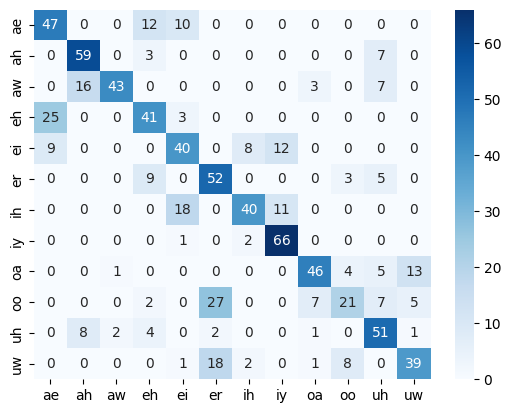

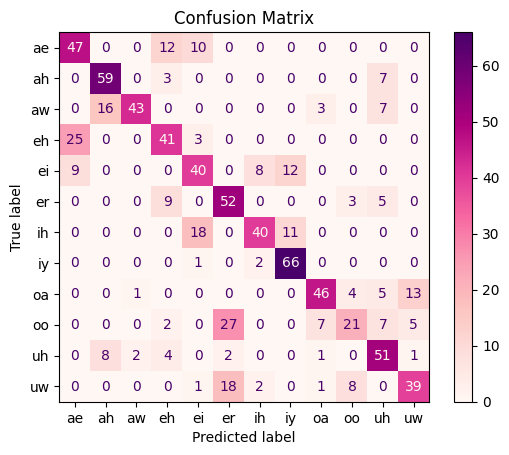

In [58]:

#Will use the classifier on the samples in test data
true_labels = []
predicted_labels = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, covariance_matrices)
        true_labels.append(vowel)
        predicted_labels.append(predicted_vowel)
        
# Make confusion matrix and error rate to analyse the clasifier
conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(vowel_data.keys()))
error_rate = 1 - accuracy_score(true_labels, predicted_labels)


#Usikker på hvilken stil:)
#eksempel på en litt finere fremstilling
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_data.keys(), yticklabels=test_data.keys())

print("Forvirringsmatrise (full kovarians):")
print(conf_matrix)
print(f"Feilrate: {error_rate*100:.2f}%")

#eventuelt:

# Bruke ConfusionMatrixDisplay 
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=test_data.keys())
disp.plot(cmap="RdPu")  # Fungerer i Blues også
plt.title("Confusion Matrix")
plt.show()

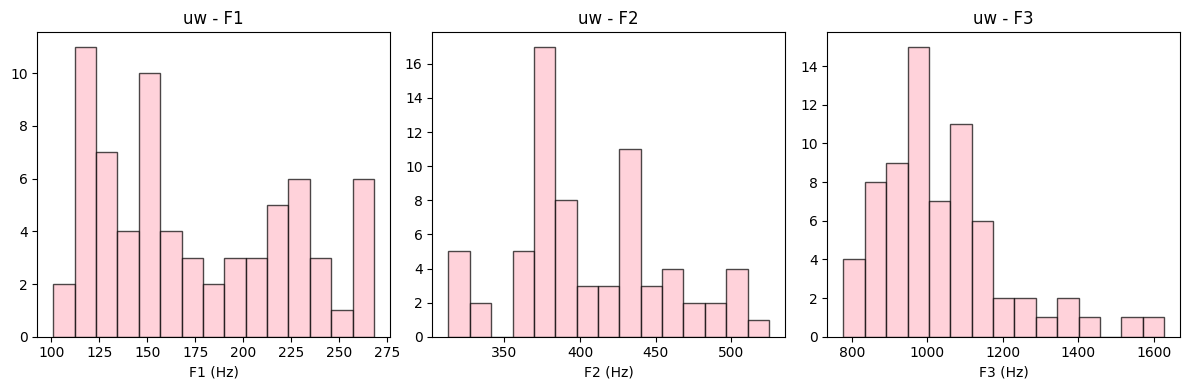

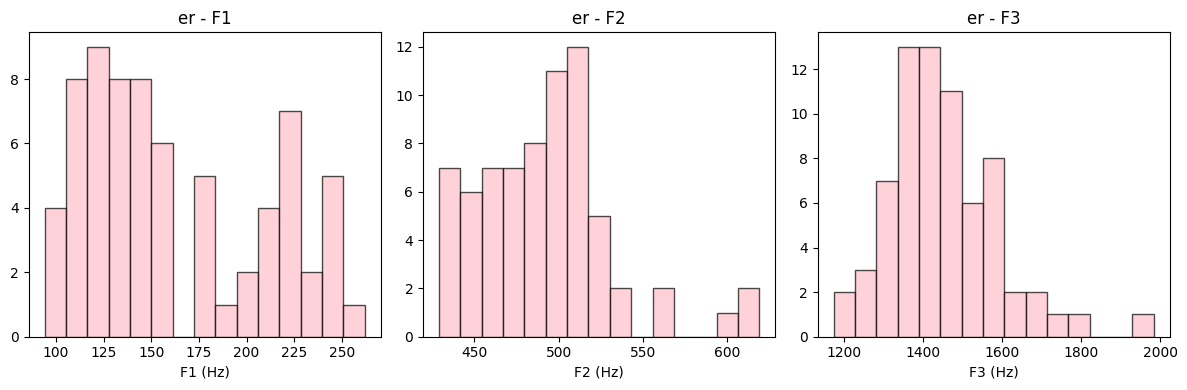

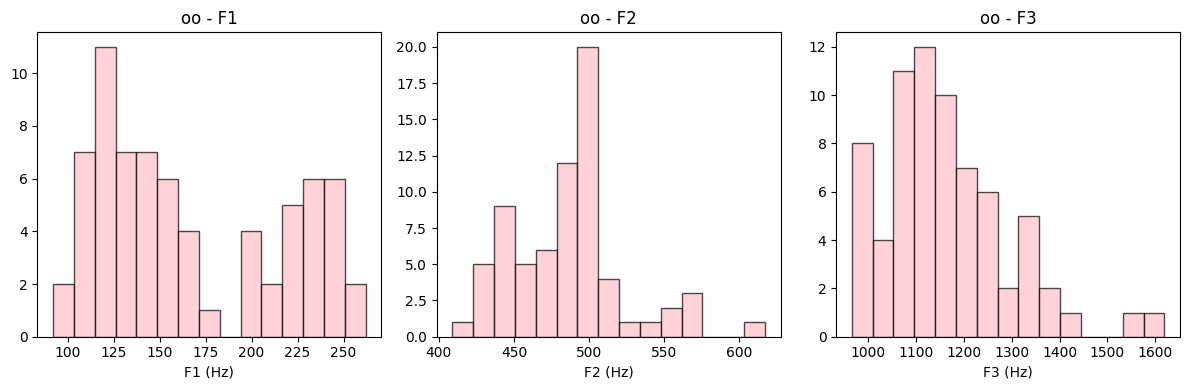

In [69]:
# Velg hvilke vokaler du vil plotte
selected_vowels = {"oo", "uw", "er"}  # Endre dette etter behov

for vowel in selected_vowels & train_data.keys():  # Sjekker at vokalen finnes i train_data
    formant_values = np.array(train_data[vowel])  
    formant_data = {"F1": formant_values[:, 0], "F2": formant_values[:, 1], "F3": formant_values[:, 2]}

    plt.figure(figsize=(12, 4))
    for i, (formant, values) in enumerate(formant_data.items(), 1):
        plt.subplot(1, 3, i)
        plt.hist(values, bins=15, color="pink", edgecolor="black", alpha=0.7)
        plt.xlabel(f"{formant} (Hz)")
        plt.title(f"{vowel} - {formant}")

    plt.tight_layout()
    plt.show()



In [45]:
# Make diagonal covariance matrix by multiplying whit identity matrix
diag_cov_matrices = {}

for vowel in mean_vectors:
    identity_matrix = np.identity(3)
    diag_cov_matrices[vowel] = covariance_matrices[vowel]*identity_matrix
    print(f'Diagonal matrix for {vowel}:\n {diag_cov_matrices[vowel]}\n ')



Diagonal matrix for ae:
 [[ 2284.16335404     0.             0.        ]
 [    0.          3955.44182195     0.        ]
 [    0.             0.         53592.91697723]]
 
Diagonal matrix for ah:
 [[ 2101.47743271     0.             0.        ]
 [    0.         11336.21718427     0.        ]
 [    0.             0.         25913.91718427]]
 
Diagonal matrix for aw:
 [[ 2260.21118012     0.             0.        ]
 [    0.          7057.89668737     0.        ]
 [    0.             0.         15766.26521739]]
 
Diagonal matrix for eh:
 [[ 2227.78467909     0.             0.        ]
 [    0.          7472.31138716     0.        ]
 [    0.             0.         30626.62857143]]
 
Diagonal matrix for ei:
 [[ 2399.22670807     0.             0.        ]
 [    0.          3431.08178054     0.        ]
 [    0.             0.         61555.37080745]]
 
Diagonal matrix for er:
 [[ 2261.573706       0.             0.        ]
 [    0.          1587.15031056     0.        ]
 [    0.           

In [46]:
# Classify and make confusion matrix and error rate with diagonal covariance matrix
predicted_labels_diag = []

for vowel, samples in test_data.items():
    for sample in samples:
        predicted_vowel = classify_sample(sample, mean_vectors, diag_cov_matrices)
        predicted_labels_diag.append(predicted_vowel)

conf_matrix_diag = confusion_matrix(true_labels, predicted_labels_diag, labels=list(vowel_data.keys()))
error_rate_diag = 1 - accuracy_score(true_labels, predicted_labels_diag)

print("Forvirringsmatrise (diagonal kovarians):")
print(conf_matrix_diag)
print(f"Feilrate: {error_rate_diag*100:.2f}%")


Forvirringsmatrise (diagonal kovarians):
[[54  0  0  7  8  0  0  0  0  0  0  0]
 [ 0 63  0  5  0  0  0  0  0  0  1  0]
 [ 0 38 22  0  0  0  0  0  1  0  8  0]
 [36  0  0 32  1  0  0  0  0  0  0  0]
 [13  0  0  0 48  0  1  7  0  0  0  0]
 [ 4  0  0 33  1 23  2  0  0  0  6  0]
 [ 0  0  0  0 51  0  7 11  0  0  0  0]
 [ 0  0  0  0  8  0  1 60  0  0  0  0]
 [ 0  1 11  0  0  0  0  0 23  3 22  9]
 [ 0  0  0 11  0 22  0  0  2 20 13  1]
 [ 0 39  1  9  0  0  0  0  0  0 19  1]
 [ 0  0  0  2  2 19  3  0  5 27  0 11]]
Feilrate: 53.86%


Dårligere, gir mening siden vi kun bruker diagonalen av covariansmartrisen, som er det samme som å anta uavhengighet mellom featurene. Det er vel litt naivt...

Er det kanskje litt vel dårlig?


# Oppgave 2

In [47]:
from sklearn.mixture import GaussianMixture


bruker bare trening og testdata jeg har fra hør,
har train_data og test_data

In [48]:
# Function to train GMM models
def train_gmm_models(train_data, n_components):
    gmm_models = {}
    
    for vowel, samples in train_data.items():
        gmm = GaussianMixture(n_components=n_components, covariance_type='diag', random_state=42)
        gmm.fit(samples)
        gmm_models[vowel] = gmm
    
    return gmm_models 

In [49]:
# Function to classify a sample for the GMM model
def classify_sample_gmm(sample, gmm_models):
    max_log_likelihood = -np.inf 
    best_class = None 
    
    for vowel, gmm in gmm_models.items():
        log_likelihood = gmm.score_samples(sample.reshape(1, -1))[0] #skjønner ikke helt shapinga
        
        if log_likelihood > max_log_likelihood:
            max_log_likelihood = log_likelihood
            best_class = vowel
    
    return best_class

In [50]:
#updated evaluation that can be used for gmm models
def evaluate_classifier(test_data, gmm_models):
    true_labels = []
    predicted_labels = []
    
    for vowel, samples in test_data.items():
        for sample in samples:
            predicted_vowel = classify_sample_gmm(sample, gmm_models)
            true_labels.append(vowel)
            predicted_labels.append(predicted_vowel)
    
    conf_matrix = confusion_matrix(true_labels, predicted_labels, labels=list(test_data.keys()))
    error_rate = 1 - accuracy_score(true_labels, predicted_labels)
    
    return conf_matrix, error_rate


In [51]:

# Train GMM models (for 2 and 3)
gmm_models_2 = train_gmm_models(train_data, n_components=2)
gmm_models_3 = train_gmm_models(train_data, n_components=3)

# Evaluate classifiers
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)

#print, fix format later:)
print("Forvirringsmatrise (GMM, 2 komponenter):")
print(conf_matrix_2)
print(f"Feilrate: {error_rate_2*100:.2f}")

print("\nForvirringsmatrise (GMM, 3 komponenter):")
print(conf_matrix_3)
print(f"Feilrate: {error_rate_3*100:.2f}")


Forvirringsmatrise (GMM, 2 komponenter):
[[41  0  0 14 13  0  1  0  0  0  0  0]
 [ 0 58  3  3  0  0  0  0  0  0  5  0]
 [ 0 18 39  0  0  0  0  0  5  0  7  0]
 [22  0  0 44  3  0  0  0  0  0  0  0]
 [ 8  0  0  0 37  0  8 16  0  0  0  0]
 [ 0  0  0 10  0 52  0  0  0  1  6  0]
 [ 0  0  0  0 22  0 34 13  0  0  0  0]
 [ 0  0  0  0  0  0  1 68  0  0  0  0]
 [ 0  1  2  0  0  0  0  0 39  6  5 16]
 [ 0  0  0  1  0 29  0  0  4 19 10  6]
 [ 0 13  2  4  0  1  0  0  1  0 47  1]
 [ 0  0  0  0  0 18  3  0  0 11  0 37]]
Feilrate: 37.80

Forvirringsmatrise (GMM, 3 komponenter):
[[41  0  0 14 13  0  1  0  0  0  0  0]
 [ 0 58  2  3  0  0  0  0  1  0  5  0]
 [ 0 16 40  0  0  0  0  0  5  0  8  0]
 [23  0  0 44  2  0  0  0  0  0  0  0]
 [ 8  0  0  0 37  0  8 16  0  0  0  0]
 [ 0  0  0  5  0 55  0  0  0  2  6  1]
 [ 0  0  0  0 22  0 34 13  0  0  0  0]
 [ 0  0  0  0  0  0  1 68  0  0  0  0]
 [ 0  1  0  0  0  0  0  0 41  8  6 13]
 [ 0  0  0  1  0 28  0  0  8 20  7  5]
 [ 0 14  2  4  0  2  0  0  0  1 46  0]
 [ 

**(d) Compare the performances for all four model types (tasks 1b, 1c and 2c). For
which class(es) is the difference largest?**

- Ser at det er best performance for GMM 3 blandt de med kun diagonal, men ikke så stor forskjell fra GMM 2
- Vanlig full covarians er best, kan se for full covarian på de to siste om det blir bedre?
- GMM2 er best på de første, gmm 3 er best på de siste
- Må vel sammenligne mer nøye

In [52]:
#Setter full covariansmatriser

def train_gmm_models_full(train_data, n_components):
    gmm_models = {}
    
    for vowel, samples in train_data.items():
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(samples)
        gmm_models[vowel] = gmm
    
    return gmm_models 

# Tren GMM-modeller med 2 og 3 komponenter
gmm_models_2 = train_gmm_models_full(train_data, n_components=2)
gmm_models_3 = train_gmm_models_full(train_data, n_components=3)

# Evaluere modellene, 2 og 2 gmm
conf_matrix_2, error_rate_2 = evaluate_classifier(test_data, gmm_models_2)
conf_matrix_3, error_rate_3 = evaluate_classifier(test_data, gmm_models_3)


print("Forvirringsmatrise (GMM med fullcovarians, 2 komponenter):")
print(conf_matrix_2)
print(f"Feilrate: {error_rate_2*100:.2f}")

print("\nForvirringsmatrise (GMM med full kovarians, 3 komponenter):")
print(conf_matrix_3)
print(f"Feilrate: {error_rate_3*100:.2f}")

Forvirringsmatrise (GMM med fullcovarians, 2 komponenter):
[[42  0  0 14 12  0  1  0  0  0  0  0]
 [ 0 56  3  4  0  0  0  0  0  0  6  0]
 [ 0 13 45  0  0  0  0  0  4  0  7  0]
 [26  0  0 42  1  0  0  0  0  0  0  0]
 [ 8  0  0  0 40  0 10 11  0  0  0  0]
 [ 0  0  0  6  0 51  0  0  0  4  7  1]
 [ 0  0  0  0 21  0 38 10  0  0  0  0]
 [ 0  0  0  0  4  0  2 63  0  0  0  0]
 [ 0  2  1  0  0  0  0  0 45  9  5  7]
 [ 0  0  0  1  0 25  0  0  3 26  9  5]
 [ 0 10  2  4  0  1  0  0  1  1 50  0]
 [ 0  0  0  0  1 10  1  0  1  8  0 48]]
Feilrate: 34.06

Forvirringsmatrise (GMM med full kovarians, 3 komponenter):
[[42  0  0 14 12  0  1  0  0  0  0  0]
 [ 0 56  3  4  0  0  0  0  0  0  6  0]
 [ 0 15 37  0  0  0  0  0  9  1  7  0]
 [26  0  0 42  1  0  0  0  0  0  0  0]
 [ 8  0  0  0 40  0 12  9  0  0  0  0]
 [ 0  0  0  7  0 41  2  0  0 11  5  3]
 [ 0  0  0  0 21  0 39  9  0  0  0  0]
 [ 0  0  0  0  7  0  1 61  0  0  0  0]
 [ 0  1  0  0  0  1  0  0 41 12  6  8]
 [ 0  0  0  2  0 19  0  0  6 30  5  7]
 [ 0 

Definitivt best, men usikker på om dette er del av oppgaven... Men her er plutselig 2 bedre enn 3